# Практикум: Классический ML, Валидация, Underfitting/Overfitting, K-Fold CV

**Цель:** отработка теории:
- Bias-Variance Tradeoff
- Underfitting vs Overfitting
- Learning Curves & Validation Curves
- K-Fold Cross-Validation (математика + sklearn)
- StratifiedKFold, GroupKFold, TimeSeriesSplit
- Nested CV
- Data Leakage
- Визуализация разбиений фолдов

**Источники:**
- Scikit-Learn Official Documentation
- Курс А.Г. Дьяконова (МГУ, факультет ВМК)

**Примечание:** везде используется современный NumPy Generator API (`np.random.default_rng`).


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    KFold, StratifiedKFold, GroupKFold, TimeSeriesSplit,
    ShuffleSplit, LeaveOneOut, cross_val_score, cross_validate,
    GridSearchCV, train_test_split, learning_curve, validation_curve
)
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, accuracy_score, make_scorer
from sklearn.datasets import make_classification, make_regression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

rng = np.random.default_rng(seed=42)

## Раздел 1: Генерация синтетических данных (Pandas + NumPy)

Генерируем данные с истинной полиномиальной зависимостью 3-й степени и аддитивным гауссовским шумом:

$$y = 2 + 3x - 0.5x^2 + 0.1x^3 + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma^2)$$


In [5]:
def generate_regression_data(n_samples=200, noise_std=15.0, rng=None):
    if rng is None:
        rng = np.random.default_rng(seed=42)
    X = np.linspace(-5, 5, n_samples)
    y_true = 2 + 3*X - 0.5*X**2 + 0.1*X**3
    epsilon = rng.normal(0, noise_std, size=n_samples)
    y = y_true + epsilon
    return pd.DataFrame({'x': X, 'y': y, 'y_true': y_true, 'noise': epsilon})

reg_df = generate_regression_data(n_samples=200, noise_std=15.0, rng=rng)
print(reg_df.head(10))
print(f'Размер выборки: {len(reg_df)}')
print(f'Средний шум: {reg_df["noise"].mean():.4f}')
print(f'Std шума: {reg_df["noise"].std():.4f}')

          x          y     y_true      noise
0 -5.000000 -40.694171 -38.000000  -2.694171
1 -4.949749 -34.274502 -37.226143   2.951641
2 -4.899497 -24.154384 -36.462311  12.307927
3 -4.849246 -41.614545 -35.708427  -5.906118
4 -4.798995 -27.146907 -34.964416   7.817509
5 -4.748744 -38.217783 -34.230201  -3.987582
6 -4.698492 -35.268838 -33.505706  -1.763133
7 -4.648241 -20.348069 -32.790855  12.442786
8 -4.597990 -61.981477 -32.085571 -29.895906
9 -4.547739 -50.836865 -31.389780 -19.447085
Размер выборки: 200
Средний шум: -1.0218
Std шума: 15.2476


## Раздел 2: Underfitting vs Optimal Fit vs Overfitting

Демонстрируем на полиномиальной регрессии разных степеней:
- **degree=1** -> underfitting (слишком просто, high bias)
- **degree=3** -> optimal fit (истинная степень)
- **degree=25** -> overfitting (слишком сложно, запоминает шум, high variance)


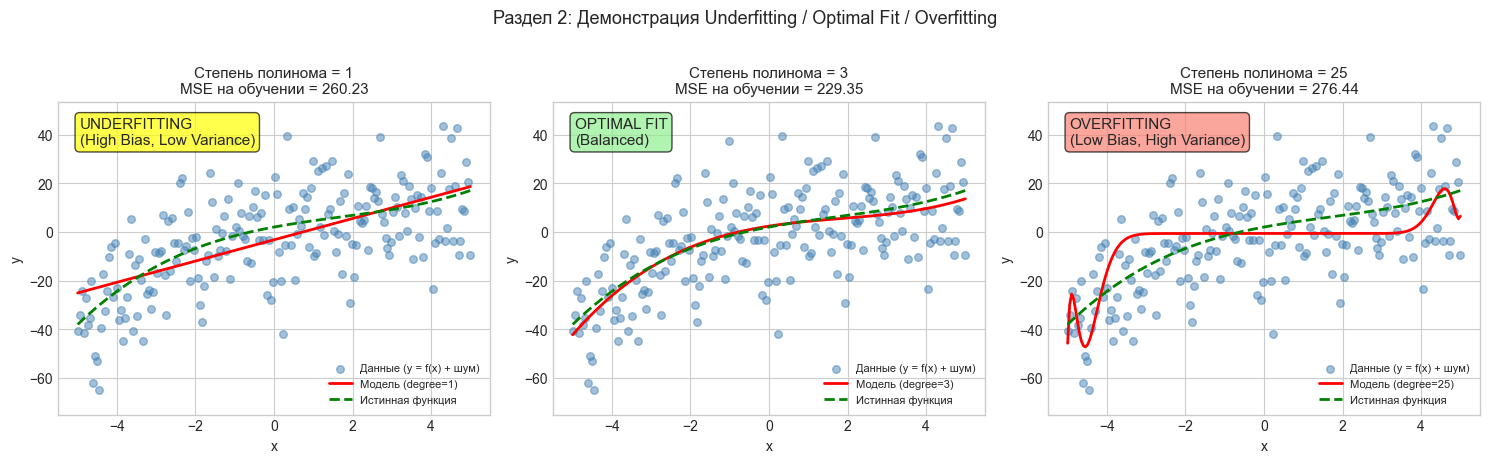

In [11]:
X = reg_df['x'].values.reshape(-1, 1)
y = reg_df['y'].values

degrees = [1, 3, 25]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, deg in zip(axes, degrees):
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
        ('linreg', LinearRegression())
    ])
    model.fit(X, y)
    y_pred = model.predict(X)
    mse = mean_squared_error(y, y_pred)

    ax.scatter(X, y, c='steelblue', alpha=0.5, s=30, label='Данные (y = f(x) + шум)')
    ax.plot(X, y_pred, 'r-', linewidth=2, label=f'Модель (degree={deg})')
    ax.plot(reg_df['x'], reg_df['y_true'], 'g--', linewidth=2, label='Истинная функция')
    ax.set_title(f'Степень полинома = {deg}\nMSE на обучении = {mse:.2f}', fontsize=11)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(fontsize=8)
    ax.set_ylim(reg_df['y'].min() - 10, reg_df['y'].max() + 10)

axes[0].text(0.05, 0.95, 'UNDERFITTING\n(High Bias, Low Variance)', 
             transform=axes[0].transAxes,
             fontsize=11,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7)
            )
axes[1].text(0.05, 0.95, 'OPTIMAL FIT\n(Balanced)', 
             transform=axes[1].transAxes,
             fontsize=11,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7)
            )
axes[2].text(0.05, 0.95, 'OVERFITTING\n(Low Bias, High Variance)', 
             transform=axes[2].transAxes,
             fontsize=11,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='salmon', alpha=0.7)
            )

plt.suptitle('Раздел 2: Демонстрация Underfitting / Optimal Fit / Overfitting', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('section2_underfitting_overfitting.png', dpi=150, bbox_inches='tight')
plt.show()

## Раздел 3: Эмпирическое Bias-Variance разложение

Согласно теории: $\text{MSE} = \text{Bias}^2 + \text{Variance} + \text{IrreducibleError}$

Многократно генерируем выборки, обучаем модель одной сложности и оцениваем каждую компоненту в фиксированной точке $x_0 = 2$.


Degree= 1:  Bias2=    0.00  Variance=    7.69  MSE=    7.69  B2+V+sigma2=  232.69
Degree= 2:  Bias2=    5.10  Variance=    9.17  MSE=   14.27  B2+V+sigma2=  239.27
Degree= 3:  Bias2=    0.01  Variance=   16.02  MSE=   16.04  B2+V+sigma2=  241.04
Degree= 5:  Bias2=    0.00  Variance=   19.29  MSE=   19.29  B2+V+sigma2=  244.29
Degree=10:  Bias2=    8.76  Variance=   20.05  MSE=   28.81  B2+V+sigma2=  253.81
Degree=20:  Bias2=   46.69  Variance=    7.68  MSE=   54.38  B2+V+sigma2=  279.38
 degree   bias_sq  variance       mse  bias_sq + var + noise
      1  0.002086  7.687870  7.689956             232.689956
      2  5.100265  9.168003 14.268267             239.268267
      3  0.011562 16.024381 16.035942             241.035942
      5  0.001118 19.289443 19.290561             244.290561
     10  8.761228 20.046251 28.807479             253.807479
     20 46.694276  7.683903 54.378179             279.378179


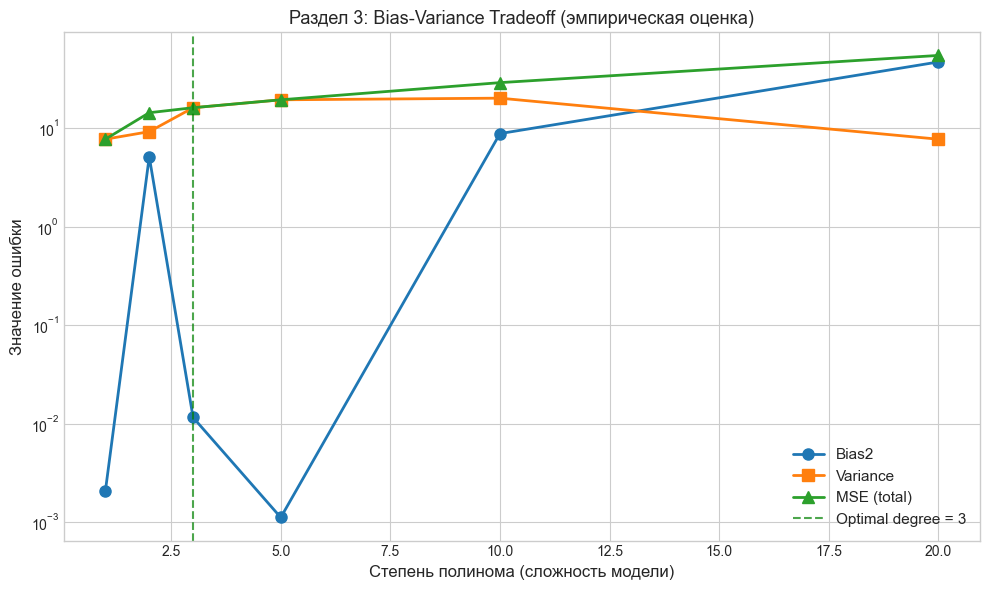

In [12]:
def empirical_bias_variance(degree, n_samples=50, n_trials=500, noise_std=15.0, rng=None):
    if rng is None:
        rng = np.random.default_rng(seed=42)
    x0 = 2.0
    y_true_at_x0 = 2 + 3 * x0 - 0.5 * x0 ** 2 + 0.1 * x0 ** 3
    predictions = []
    for _ in range(n_trials):
        X_train = rng.uniform(-5, 5, n_samples).reshape(-1, 1)
        epsilon = rng.normal(0, noise_std, n_samples)
        y_train = (2 + 3*X_train.ravel() - 0.5*X_train.ravel()**2 + 
                   0.1*X_train.ravel()**3 + epsilon)
        model = Pipeline([
            ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
            ('linreg', LinearRegression())
        ])
        model.fit(X_train, y_train)
        pred = model.predict(np.array([[x0]]))[0]
        predictions.append(pred)

    predictions = np.array(predictions)
    mean_pred = predictions.mean()
    bias_sq = (y_true_at_x0 - mean_pred) ** 2
    variance = predictions.var()
    mse = ((y_true_at_x0 - predictions) ** 2).mean()
    irreducible = noise_std ** 2
    return bias_sq, variance, mse, irreducible

results = []
for deg in [1, 2, 3, 5, 10, 20]:
    b2, var, mse, irr = empirical_bias_variance(deg, rng=rng)
    results.append({'degree': deg, 'bias_sq': b2, 'variance': var, 'mse': mse, 'bias_sq + var + noise': b2 + var + irr})
    print(f'Degree={deg:2d}:  Bias2={b2:8.2f}  Variance={var:8.2f}  MSE={mse:8.2f}  B2+V+sigma2={b2+var+irr:8.2f}')

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(results_df['degree'], results_df['bias_sq'], 'o-', label='Bias2', linewidth=2, markersize=8)
ax.plot(results_df['degree'], results_df['variance'], 's-', label='Variance', linewidth=2, markersize=8)
ax.plot(results_df['degree'], results_df['mse'], '^-', label='MSE (total)', linewidth=2, markersize=8)
ax.axvline(x=3, color='green', linestyle='--', alpha=0.7, label='Optimal degree = 3')
ax.set_xlabel('Степень полинома (сложность модели)', fontsize=12)
ax.set_ylabel('Значение ошибки', fontsize=12)
ax.set_title('Раздел 3: Bias-Variance Tradeoff (эмпирическая оценка)', fontsize=13)
ax.legend(fontsize=11)
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('section3_bias_variance.png', dpi=150, bbox_inches='tight')
plt.show()

## Раздел 4: Learning Curves (кривые обучения)

Learning curve показывает зависимость train/validation error от размера обучающей выборки. Диагностирует underfitting/overfitting.


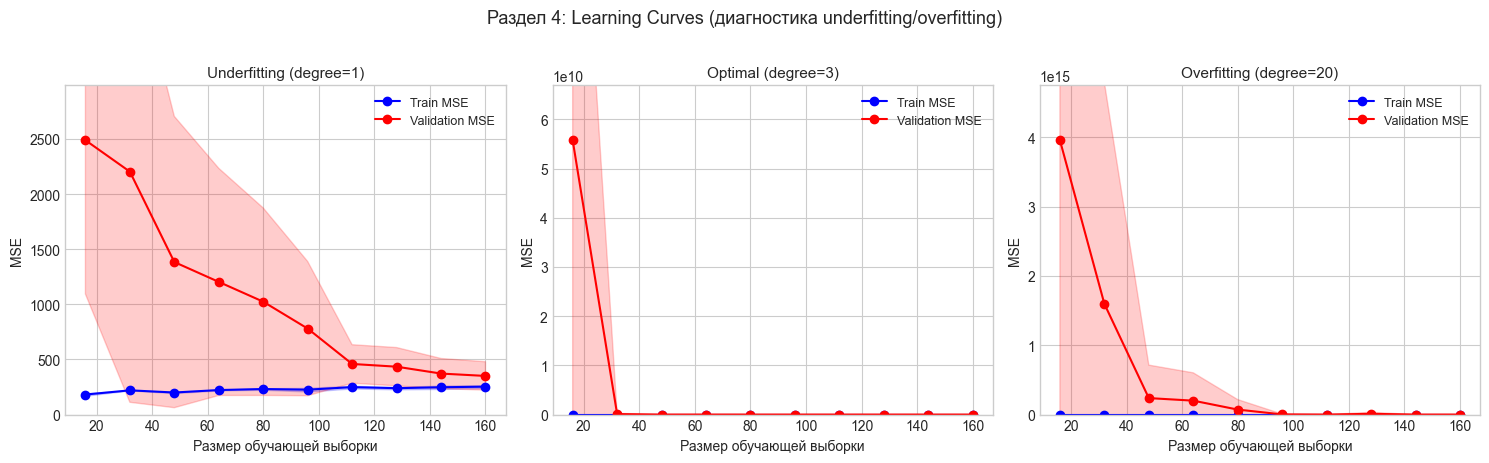

In [13]:
models_lc = {
    'Underfitting (degree=1)': Pipeline([
        ('poly', PolynomialFeatures(degree=1, include_bias=False)),
        ('linreg', LinearRegression())
    ]),
    'Optimal (degree=3)': Pipeline([
        ('poly', PolynomialFeatures(degree=3, include_bias=False)),
        ('linreg', LinearRegression())
    ]),
    'Overfitting (degree=20)': Pipeline([
        ('poly', PolynomialFeatures(degree=20, include_bias=False)),
        ('linreg', LinearRegression())
    ])
}

X_full = reg_df['x'].values.reshape(-1, 1)
y_full = reg_df['y'].values
train_sizes = np.linspace(0.1, 1.0, 10)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (name, model) in zip(axes, models_lc.items()):
    train_sizes_abs, train_scores, test_scores = learning_curve(
        model, X_full, y_full, train_sizes=train_sizes, cv=5,
        scoring='neg_mean_squared_error', n_jobs=-1, random_state=42)
    train_scores = -train_scores
    test_scores = -test_scores

    ax.plot(train_sizes_abs, train_scores.mean(axis=1), 'o-', color='blue', label='Train MSE')
    ax.fill_between(train_sizes_abs, 
                    train_scores.mean(axis=1) - train_scores.std(axis=1),
                    train_scores.mean(axis=1) + train_scores.std(axis=1),
                    alpha=0.2, color='blue')
    ax.plot(train_sizes_abs, test_scores.mean(axis=1), 'o-', color='red', label='Validation MSE')
    ax.fill_between(train_sizes_abs,
                    test_scores.mean(axis=1) - test_scores.std(axis=1),
                    test_scores.mean(axis=1) + test_scores.std(axis=1),
                    alpha=0.2, color='red')
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Размер обучающей выборки')
    ax.set_ylabel('MSE')
    ax.legend(fontsize=9)
    ax.set_ylim(0, max(test_scores.mean(axis=1).max(), train_scores.mean(axis=1).max()) * 1.2)

plt.suptitle('Раздел 4: Learning Curves (диагностика underfitting/overfitting)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('section4_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## Раздел 5: Validation Curves (кривые валидации)

Validation curve показывает зависимость train/validation error от гиперпараметра сложности (здесь -- степень полинома).


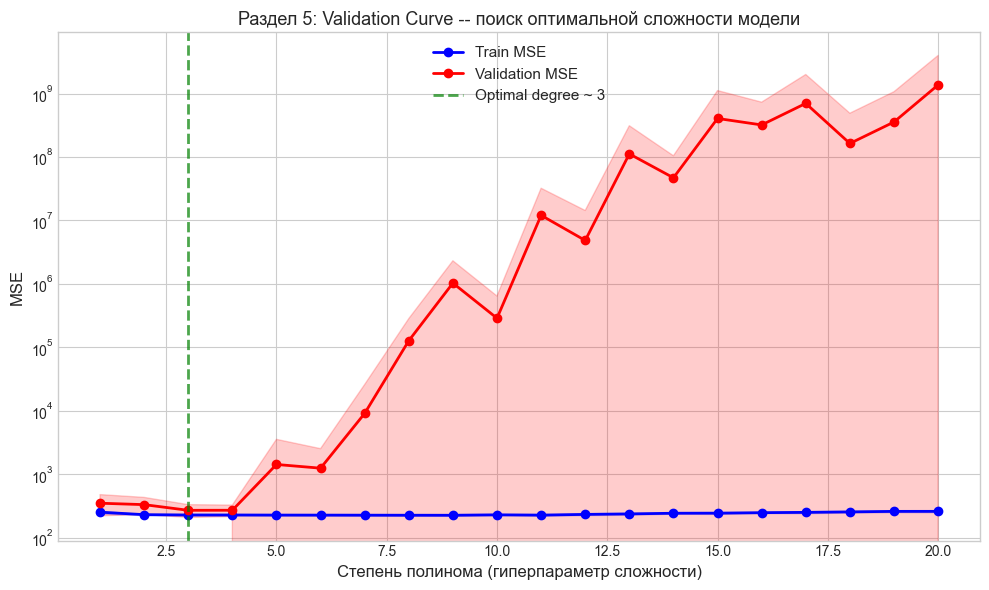

In [14]:
param_range = list(range(1, 21))
pipeline_vc = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('linreg', LinearRegression())
])

train_scores_vc, test_scores_vc = validation_curve(
    pipeline_vc, X_full, y_full,
    param_name='poly__degree', param_range=param_range,
    cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

train_scores_vc = -train_scores_vc
test_scores_vc = -test_scores_vc

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(param_range, train_scores_vc.mean(axis=1), 'o-', color='blue', label='Train MSE', linewidth=2)
ax.fill_between(param_range,
                train_scores_vc.mean(axis=1) - train_scores_vc.std(axis=1),
                train_scores_vc.mean(axis=1) + train_scores_vc.std(axis=1),
                alpha=0.2, color='blue')
ax.plot(param_range, test_scores_vc.mean(axis=1), 'o-', color='red', label='Validation MSE', linewidth=2)
ax.fill_between(param_range,
                test_scores_vc.mean(axis=1) - test_scores_vc.std(axis=1),
                test_scores_vc.mean(axis=1) + test_scores_vc.std(axis=1),
                alpha=0.2, color='red')
ax.axvline(x=3, color='green', linestyle='--', alpha=0.7, linewidth=2, label='Optimal degree ~ 3')
ax.set_xlabel('Степень полинома (гиперпараметр сложности)', fontsize=12)
ax.set_ylabel('MSE', fontsize=12)
ax.set_title('Раздел 5: Validation Curve -- поиск оптимальной сложности модели', fontsize=13)
ax.legend(fontsize=11)
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('section5_validation_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## Раздел 6: K-Fold Cross-Validation -- реализация с нуля

Реализуем K-Fold CV вручную, чтобы понять математику:

$$\widehat{R}_{CV} = \frac{1}{K} \sum_{k=1}^{K} \frac{1}{|C_k|} \sum_{(x,y) \in C_k} L(y, \hat{f}^{(-k)}(x))$$

Используем `rng.permutation` для перемешивания индексов (современный Generator API).


In [15]:
def kfold_cv_from_scratch(X, y, model, k=5, metric_fn=mean_squared_error, shuffle=True, rng=None):
    if rng is None:
        rng = np.random.default_rng(seed=42)
    n = len(X)
    indices = np.arange(n)
    if shuffle:
        indices = rng.permutation(indices)
    fold_size = n // k
    scores = []
    fold_indices = []
    print(f'\n--- K-Fold CV с нуля (K={k}, n={n}) ---')
    print(f'Размер каждого фолда: примерно {fold_size} объектов')
    for fold in range(k):
        start = fold * fold_size
        end = start + fold_size if fold < k - 1 else n
        test_idx = indices[start:end]
        train_idx = np.concatenate([indices[:start], indices[end:]])
        fold_indices.append((train_idx, test_idx))
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        score = metric_fn(y_test, y_pred)
        scores.append(score)
        print(f'  Фолд {fold+1}: train={len(train_idx)}, test={len(test_idx)}, MSE={score:.4f}')
    mean_score = np.mean(scores)
    std_score = np.std(scores)
    print(f'\n  Итоговая оценка CV:')
    print(f'    R_cv = (1/{k}) * sum(e_k) = {mean_score:.4f} (+/- {std_score:.4f})')
    return scores, mean_score, std_score, fold_indices

model_lr = LinearRegression()
scores_manual, mean_manual, std_manual, folds = kfold_cv_from_scratch(
    X_full, y_full, model_lr, k=5, metric_fn=mean_squared_error, rng=rng)

scores_sklearn = cross_val_score(
    model_lr, X_full, y_full, 
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='neg_mean_squared_error')
scores_sklearn = -scores_sklearn
print(f'\n  Сравнение со sklearn KFold:')
print(f'    sklearn mean MSE = {scores_sklearn.mean():.4f} (+/- {scores_sklearn.std():.4f})')
print(f'    Ручная mean MSE  = {mean_manual:.4f} (+/- {std_manual:.4f})')
print(f'    Разница: {abs(scores_sklearn.mean() - mean_manual):.6f}  (должна быть ~0)')



--- K-Fold CV с нуля (K=5, n=200) ---
Размер каждого фолда: примерно 40 объектов
  Фолд 1: train=160, test=40, MSE=250.9174
  Фолд 2: train=160, test=40, MSE=268.1946
  Фолд 3: train=160, test=40, MSE=264.3575
  Фолд 4: train=160, test=40, MSE=242.0523
  Фолд 5: train=160, test=40, MSE=290.8741

  Итоговая оценка CV:
    R_cv = (1/5) * sum(e_k) = 263.2792 (+/- 16.6745)

  Сравнение со sklearn KFold:
    sklearn mean MSE = 267.9462 (+/- 15.9936)
    Ручная mean MSE  = 263.2792 (+/- 16.6745)
    Разница: 4.667044  (должна быть ~0)


## Раздел 7: Stratified K-Fold (классификация)

StratifiedKFold гарантирует сохранение пропорций классов в каждом фолде. Критически важно при несбалансированных классах.


In [16]:
X_clf, y_clf = make_classification(
    n_samples=500, n_features=10, n_informative=5, n_redundant=2,
    n_classes=3, weights=[0.5, 0.3, 0.2], random_state=42)

clf_df = pd.DataFrame(X_clf, columns=[f'feature_{i}' for i in range(10)])
clf_df['target'] = y_clf
print('Распределение классов в полной выборке:')
print(clf_df['target'].value_counts().sort_index())

kf_plain = KFold(n_splits=5, shuffle=True, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('\n--- Обычный KFold ---')
for fold, (train_idx, test_idx) in enumerate(kf_plain.split(X_clf), 1):
    y_test = y_clf[test_idx]
    proportions = pd.Series(y_test).value_counts(normalize=True).sort_index()
    print(f'  Фолд {fold}: {dict(proportions.round(3))}')

print('\n--- StratifiedKFold ---')
for fold, (train_idx, test_idx) in enumerate(skf.split(X_clf, y_clf), 1):
    y_test = y_clf[test_idx]
    proportions = pd.Series(y_test).value_counts(normalize=True).sort_index()
    print(f'  Фолд {fold}: {dict(proportions.round(3))}')

svm_clf = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
scores_kf = cross_val_score(svm_clf, X_clf, y_clf, cv=kf_plain, scoring='accuracy')
scores_skf = cross_val_score(svm_clf, X_clf, y_clf, cv=skf, scoring='accuracy')
print(f'\nAccuracy (обычный KFold):  {scores_kf.mean():.4f} (+/- {scores_kf.std():.4f})')
print(f'Accuracy (StratifiedKFold): {scores_skf.mean():.4f} (+/- {scores_skf.std():.4f})')


Распределение классов в полной выборке:
target
0    249
1    151
2    100
Name: count, dtype: int64

--- Обычный KFold ---
  Фолд 1: {0: np.float64(0.52), 1: np.float64(0.21), 2: np.float64(0.27)}
  Фолд 2: {0: np.float64(0.43), 1: np.float64(0.33), 2: np.float64(0.24)}
  Фолд 3: {0: np.float64(0.52), 1: np.float64(0.28), 2: np.float64(0.2)}
  Фолд 4: {0: np.float64(0.51), 1: np.float64(0.38), 2: np.float64(0.11)}
  Фолд 5: {0: np.float64(0.51), 1: np.float64(0.31), 2: np.float64(0.18)}

--- StratifiedKFold ---
  Фолд 1: {0: np.float64(0.49), 1: np.float64(0.31), 2: np.float64(0.2)}
  Фолд 2: {0: np.float64(0.5), 1: np.float64(0.3), 2: np.float64(0.2)}
  Фолд 3: {0: np.float64(0.5), 1: np.float64(0.3), 2: np.float64(0.2)}
  Фолд 4: {0: np.float64(0.5), 1: np.float64(0.3), 2: np.float64(0.2)}
  Фолд 5: {0: np.float64(0.5), 1: np.float64(0.3), 2: np.float64(0.2)}

Accuracy (обычный KFold):  0.9000 (+/- 0.0352)
Accuracy (StratifiedKFold): 0.8720 (+/- 0.0194)


## Раздел 8: Group K-Fold

GroupKFold гарантирует, что объекты одной группы не попадут одновременно в train и test. Важно при группированных данных (пациенты, пользователи, сенсоры).


In [17]:
n_groups = 20
objects_per_group = 5
n_total = n_groups * objects_per_group

X_group = rng.standard_normal((n_total, 5))
groups = np.repeat(np.arange(n_groups), objects_per_group)
y_group = np.array([rng.standard_normal() for g in groups]) + 0.5 * X_group[:, 0]

group_df = pd.DataFrame(X_group, columns=[f'f{i}' for i in range(5)])
group_df['group'] = groups
group_df['target'] = y_group

print(f'Всего объектов: {n_total}, групп: {n_groups}')

gkf = GroupKFold(n_splits=5)
print('\n--- GroupKFold (n_splits=5) ---')
for fold, (train_idx, test_idx) in enumerate(gkf.split(X_group, y_group, groups), 1):
    train_groups = set(groups[train_idx])
    test_groups = set(groups[test_idx])
    overlap = train_groups & test_groups
    print(f'  Фолд {fold}: пересечение групп = {len(overlap)} (должно быть 0)')

ridge_reg = Ridge(alpha=1.0)
scores_gkf = cross_val_score(ridge_reg, X_group, y_group, 
                             cv=gkf.split(X_group, y_group, groups),
                             scoring='neg_mean_squared_error')
print(f'\nGroupKFold MSE: {-scores_gkf.mean():.4f} (+/- {scores_gkf.std():.4f})')


Всего объектов: 100, групп: 20

--- GroupKFold (n_splits=5) ---
  Фолд 1: пересечение групп = 0 (должно быть 0)
  Фолд 2: пересечение групп = 0 (должно быть 0)
  Фолд 3: пересечение групп = 0 (должно быть 0)
  Фолд 4: пересечение групп = 0 (должно быть 0)
  Фолд 5: пересечение групп = 0 (должно быть 0)

GroupKFold MSE: 1.2510 (+/- 0.0811)


## Раздел 9: Time Series Split

TimeSeriesSplit учитывает временную структуру: тест -- всегда 'будущее', train -- всегда 'прошлое'. Критически важно для временных рядов.


--- TimeSeriesSplit (n_splits=5, n=100) ---
  Фолд 1: train=[  0,  19] (20 объектов), test=[ 20,  35] (16 объектов)
  Фолд 2: train=[  0,  35] (36 объектов), test=[ 36,  51] (16 объектов)
  Фолд 3: train=[  0,  51] (52 объектов), test=[ 52,  67] (16 объектов)
  Фолд 4: train=[  0,  67] (68 объектов), test=[ 68,  83] (16 объектов)
  Фолд 5: train=[  0,  83] (84 объектов), test=[ 84,  99] (16 объектов)


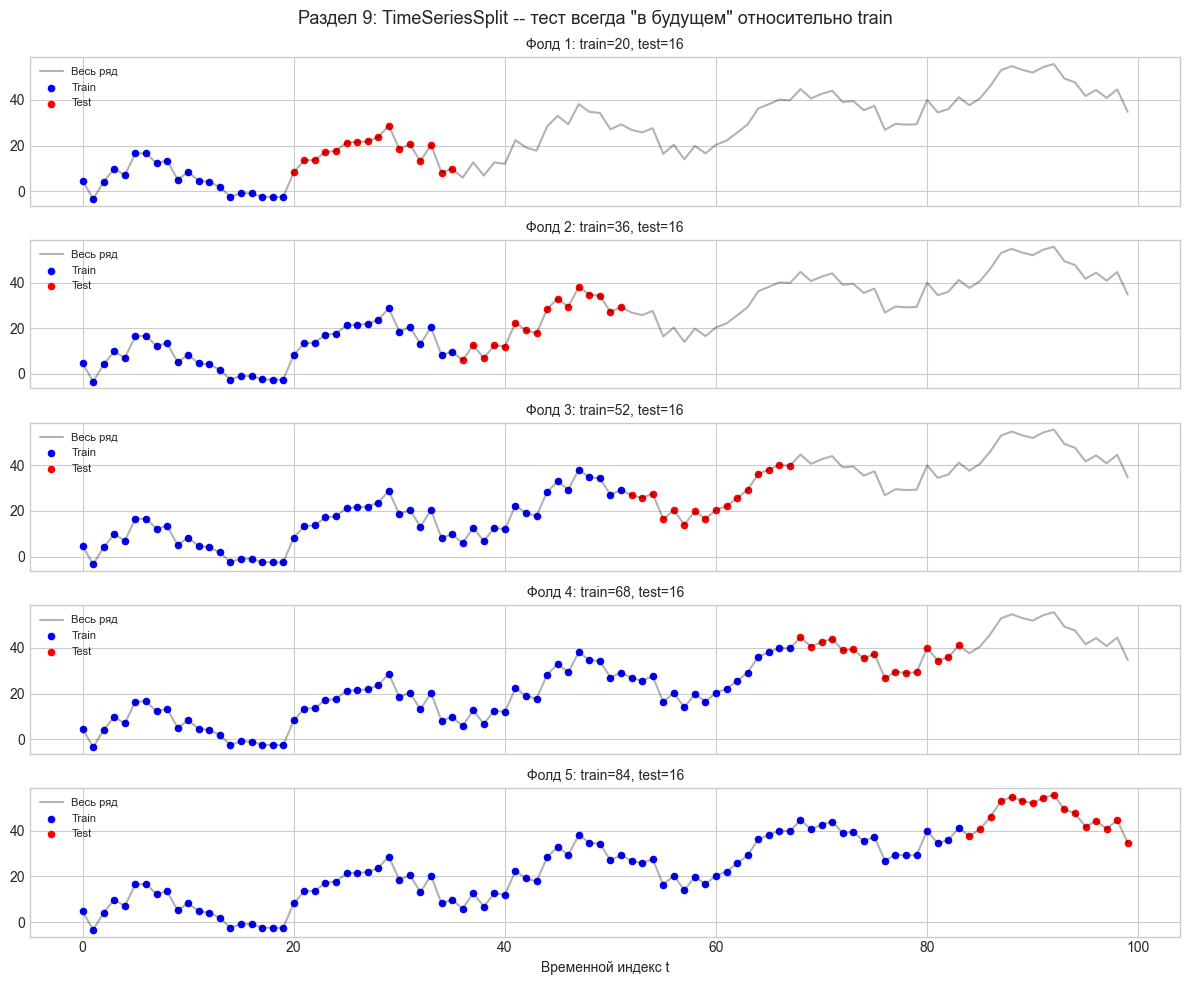

In [18]:
n_ts = 100
t = np.arange(n_ts)
y_ts = 0.5 * t + 10 * np.sin(0.3 * t) + rng.normal(0, 3, n_ts)
X_ts = t.reshape(-1, 1)

tss = TimeSeriesSplit(n_splits=5)
print(f'--- TimeSeriesSplit (n_splits=5, n={n_ts}) ---')
for fold, (train_idx, test_idx) in enumerate(tss.split(X_ts), 1):
    print(f'  Фолд {fold}: train=[{train_idx.min():3d}, {train_idx.max():3d}] '
          f'({len(train_idx)} объектов), test=[{test_idx.min():3d}, {test_idx.max():3d}] '
          f'({len(test_idx)} объектов)')

fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)
for fold, (train_idx, test_idx) in enumerate(tss.split(X_ts), 1):
    ax = axes[fold - 1]
    ax.plot(t, y_ts, 'k-', alpha=0.3, label='Весь ряд')
    ax.scatter(t[train_idx], y_ts[train_idx], c='blue', s=20, label='Train')
    ax.scatter(t[test_idx], y_ts[test_idx], c='red', s=20, label='Test')
    ax.set_title(f'Фолд {fold}: train={len(train_idx)}, test={len(test_idx)}', fontsize=10)
    ax.legend(loc='upper left', fontsize=8)

plt.suptitle('Раздел 9: TimeSeriesSplit -- тест всегда "в будущем" относительно train', fontsize=13)
plt.xlabel('Временной индекс t')
plt.tight_layout()
plt.savefig('section9_timeseries_split.png', dpi=150, bbox_inches='tight')
plt.show()


## Раздел 10: Визуализация разбиений CV

Наглядно покажем, какие индексы попадают в train/test для разных стратегий (как в sklearn examples).


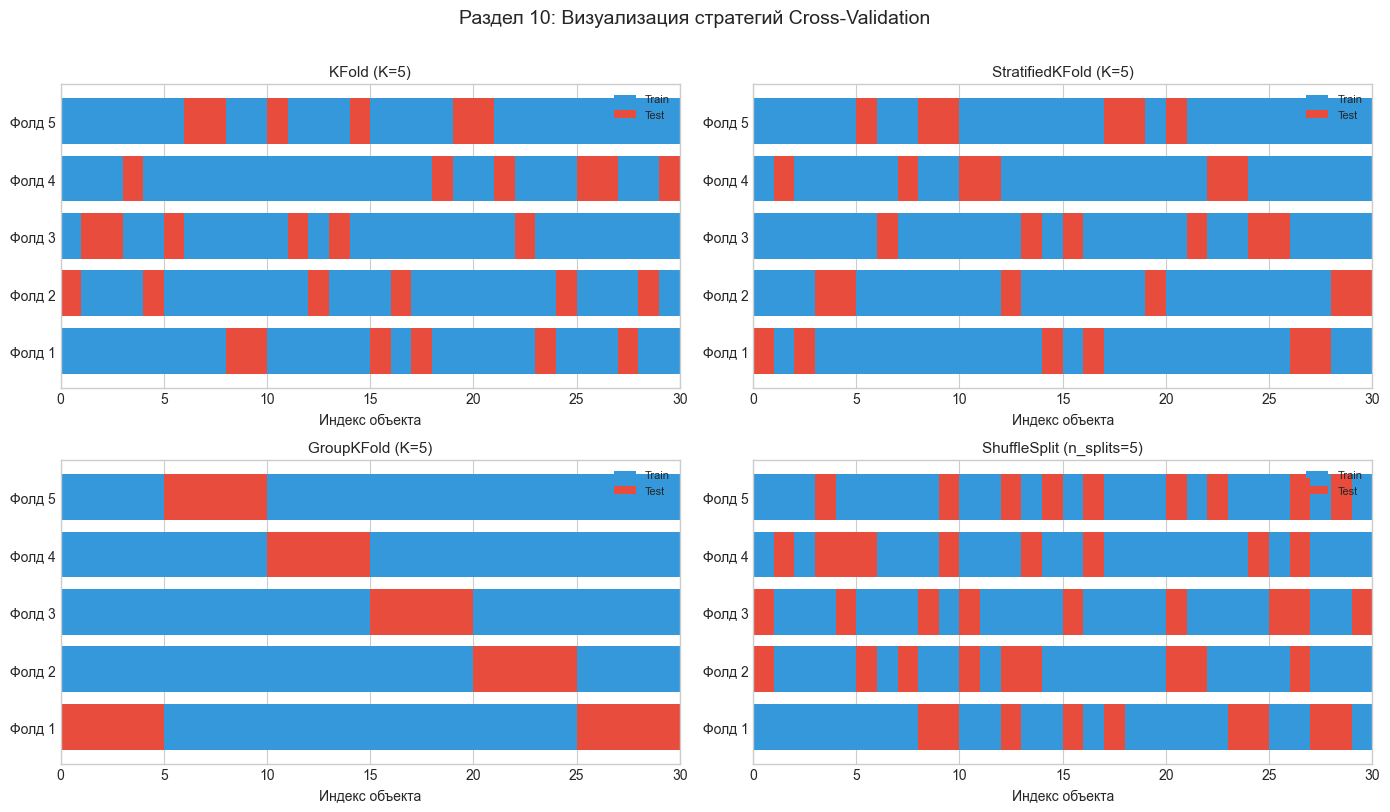

In [19]:
n_vis = 30
X_vis = np.arange(n_vis)
y_vis = rng.integers(0, 2, n_vis)
groups_vis = np.repeat(np.arange(6), 5)

cv_methods = [
    ('KFold (K=5)', KFold(n_splits=5, shuffle=True, random_state=42)),
    ('StratifiedKFold (K=5)', StratifiedKFold(n_splits=5, shuffle=True, random_state=42)),
    ('GroupKFold (K=5)', GroupKFold(n_splits=5)),
    ('ShuffleSplit (n_splits=5)', ShuffleSplit(n_splits=5, test_size=0.3, random_state=42)),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for ax, (title, cv) in zip(axes, cv_methods):
    if 'Group' in title:
        cv_iter = list(cv.split(X_vis.reshape(-1, 1), y_vis, groups_vis))
    else:
        cv_iter = list(cv.split(X_vis.reshape(-1, 1), y_vis))
    n_splits = len(cv_iter)
    for i, (train_idx, test_idx) in enumerate(cv_iter):
        y_offset = n_splits - i - 1
        for j in range(n_vis):
            color = '#3498db' if j in train_idx else '#e74c3c'
            ax.barh(y_offset, 1, left=j, color=color, edgecolor='none', height=0.8)
    ax.set_yticks(range(n_splits))
    ax.set_yticklabels([f'Фолд {i+1}' for i in range(n_splits)][::-1])
    ax.set_xlabel('Индекс объекта')
    ax.set_title(title, fontsize=11)
    ax.set_xlim(0, n_vis)
    ax.invert_yaxis()
    legend_elements = [Patch(facecolor='#3498db', label='Train'),
                       Patch(facecolor='#e74c3c', label='Test')]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=8)

plt.suptitle('Раздел 10: Визуализация стратегий Cross-Validation', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('section10_cv_visualization.png', dpi=150, bbox_inches='tight')
plt.show()


## Раздел 11: Nested Cross-Validation (вложенная CV)

Nested CV решает проблему оптимистичной оценки при одновременном подборе гиперпараметров и оценке качества.

**Структура:**
- Внешний цикл (outer): оценка обобщающей способности (K1-fold)
- Внутренний цикл (inner): подбор гиперпараметров GridSearchCV (K2-fold)


In [20]:
X_nested, y_nested = make_classification(
    n_samples=300, n_features=20, n_informative=10, n_redundant=5, random_state=42)

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

logreg = LogisticRegression(max_iter=1000, random_state=42)

outer_scores = []
print('--- Nested CV: внешний цикл (5-fold) ---')
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_nested, y_nested), 1):
    X_train, X_test = X_nested[train_idx], X_nested[test_idx]
    y_train, y_test = y_nested[train_idx], y_nested[test_idx]
    grid = GridSearchCV(logreg, param_grid, cv=inner_cv, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    test_score = accuracy_score(y_test, best_model.predict(X_test))
    outer_scores.append(test_score)
    print(f'  Фолд {fold}: best_C={grid.best_params_["C"]:.3f}, '
          f'inner_best={grid.best_score_:.4f}, outer_test={test_score:.4f}')

print(f'\nNested CV итоговая accuracy: {np.mean(outer_scores):.4f} (+/- {np.std(outer_scores):.4f})')

grid_naive = GridSearchCV(logreg, param_grid, cv=outer_cv, scoring='accuracy', n_jobs=-1)
grid_naive.fit(X_nested, y_nested)
print(f'\n(Неправильный) Non-nested CV accuracy: {grid_naive.best_score_:.4f}')
print(f'Разница (оптимизм): {grid_naive.best_score_ - np.mean(outer_scores):.4f}')
print('  -> Non-nested дает ЗАВЫШЕННУЮ оценку! Nested CV -- единственно корректный способ.')


--- Nested CV: внешний цикл (5-fold) ---
  Фолд 1: best_C=0.100, inner_best=0.8458, outer_test=0.8667
  Фолд 2: best_C=0.100, inner_best=0.8500, outer_test=0.9167
  Фолд 3: best_C=0.010, inner_best=0.8750, outer_test=0.8333
  Фолд 4: best_C=0.100, inner_best=0.8917, outer_test=0.8167
  Фолд 5: best_C=1.000, inner_best=0.8625, outer_test=0.8833

Nested CV итоговая accuracy: 0.8633 (+/- 0.0356)

(Неправильный) Non-nested CV accuracy: 0.8700
Разница (оптимизм): 0.0067
  -> Non-nested дает ЗАВЫШЕННУЮ оценку! Nested CV -- единственно корректный способ.


## Раздел 12: Data Leakage (утечка данных)

Data Leakage -- когда информация из тестовой выборки 'просачивается' в обучающую. Классический пример: нормализация **всех** данных **до** разбиения.


In [21]:
X_leak = rng.standard_normal((200, 5))
y_leak = rng.standard_normal(200) + 2 * X_leak[:, 0] + 0.5 * X_leak[:, 1]

# НЕПРАВИЛЬНЫЙ способ (Data Leakage)
scaler_wrong = StandardScaler()
X_scaled_wrong = scaler_wrong.fit_transform(X_leak)
scores_wrong = cross_val_score(
    Ridge(alpha=1.0), X_scaled_wrong, y_leak,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='neg_mean_squared_error')
scores_wrong = -scores_wrong

# ПРАВИЛЬНЫЙ способ (Pipeline)
pipeline_correct = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])
scores_correct = cross_val_score(
    pipeline_correct, X_leak, y_leak,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='neg_mean_squared_error')
scores_correct = -scores_correct

print(f'MSE с Data Leakage (нормализация до CV): {scores_wrong.mean():.4f} (+/- {scores_wrong.std():.4f})')
print(f'MSE без Data Leakage (Pipeline внутри CV): {scores_correct.mean():.4f} (+/- {scores_correct.std():.4f})')
print(f'Разница (оптимизм из-за утечки): {scores_wrong.mean() - scores_correct.mean():.4f}')
print('  -> Всегда используйте Pipeline для предобработки внутри CV!')


MSE с Data Leakage (нормализация до CV): 0.9091 (+/- 0.1944)
MSE без Data Leakage (Pipeline внутри CV): 0.9090 (+/- 0.1945)
Разница (оптимизм из-за утечки): 0.0001
  -> Всегда используйте Pipeline для предобработки внутри CV!


## Раздел 13: `cross_validate` -- расширенная оценка

`cross_validate` позволяет получить `train_scores`, `fit_time`, `score_time`, а также использовать несколько метрик одновременно.


In [22]:
scoring = {
    'mse': make_scorer(mean_squared_error, greater_is_better=False),
    'mae': 'neg_mean_absolute_error'
}

cv_results = cross_validate(
    Ridge(alpha=1.0), X_full, y_full,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring=scoring, return_train_score=True, return_estimator=True)

results_summary = pd.DataFrame({
    'fold': range(1, 6),
    'fit_time': cv_results['fit_time'],
    'score_time': cv_results['score_time'],
    'train_mse': -cv_results['train_mse'],
    'test_mse': -cv_results['test_mse'],
    'test_mae': -cv_results['test_mae']
})

print(results_summary.to_string(index=False))
print(f'\nСреднее время обучения: {results_summary["fit_time"].mean():.4f} сек')
print(f'Среднее время скоринга: {results_summary["score_time"].mean():.4f} сек')


 fold  fit_time  score_time  train_mse   test_mse  test_mae
    1  0.001480    0.001034 262.983637 251.833408 12.956588
    2  0.001475    0.001265 261.673835 257.878513 12.855779
    3  0.001904    0.001968 264.196383 256.149664 12.584803
    4  0.001354    0.002336 252.540726 291.989991 13.381976
    5  0.001754    0.001004 255.522404 281.879240 13.697210

Среднее время обучения: 0.0016 сек
Среднее время скоринга: 0.0015 сек


## Раздел 14: Сводная таблица результатов


In [24]:
summary = pd.DataFrame({
    'Метод / Эксперимент': [
        'K-Fold CV (ручная реализация)',
        'K-Fold CV (sklearn)',
        'StratifiedKFold (SVM)',
        'GroupKFold (Ridge)',
        'Nested CV (LogisticRegression)',
        'Data Leakage (неверно)',
        'Data Leakage (верно, Pipeline)'
    ],
    'Средняя метрика': [
        f'{mean_manual:.4f}',
        f'{scores_sklearn.mean():.4f}',
        f'{scores_skf.mean():.4f}',
        f'{-scores_gkf.mean():.4f}',
        f'{np.mean(outer_scores):.4f}',
        f'{scores_wrong.mean():.4f}',
        f'{scores_correct.mean():.4f}'
    ],
    'Std': [
        f'{std_manual:.4f}',
        f'{scores_sklearn.std():.4f}',
        f'{scores_skf.std():.4f}',
        f'{scores_gkf.std():.4f}',
        f'{np.std(outer_scores):.4f}',
        f'{scores_wrong.std():.4f}',
        f'{scores_correct.std():.4f}'
    ],
    'Примечание': [
        'Реализация с нуля (Generator API)',
        'Встроенная функция sklearn',
        'Сохраняет пропорции классов',
        'Группы не пересекаются',
        'Несмещенная оценка + подбор гиперпараметров',
        'Утечка данных (оптимистично)',
        'Корректная предобработка через Pipeline'
    ]
})

print(summary.to_string(index=False))
print()
print('''
Ключевые выводы:
  1. Underfitting = High Bias + Low Variance (простая модель)
  2. Overfitting  = Low Bias + High Variance (сложная модель)
  3. K-Fold CV дает надежную оценку обобщающей способности
  4. StratifiedKFold -- для классификации с дисбалансом
  5. GroupKFold -- для группированных данных
  6. TimeSeriesSplit -- для временных рядов
  7. Nested CV -- для одновременного подбора гиперпараметров и оценки
  8. ВСЕГДА используйте Pipeline, чтобы избежать Data Leakage!
  9. Используйте np.random.default_rng() вместо устаревшего np.random.seed()
''')


           Метод / Эксперимент Средняя метрика     Std                                  Примечание
 K-Fold CV (ручная реализация)        263.2792 16.6745           Реализация с нуля (Generator API)
           K-Fold CV (sklearn)        267.9462 15.9936                  Встроенная функция sklearn
         StratifiedKFold (SVM)          0.8720  0.0194                 Сохраняет пропорции классов
            GroupKFold (Ridge)          1.2510  0.0811                      Группы не пересекаются
Nested CV (LogisticRegression)          0.8633  0.0356 Несмещенная оценка + подбор гиперпараметров
        Data Leakage (неверно)          0.9091  0.1944                Утечка данных (оптимистично)
Data Leakage (верно, Pipeline)          0.9090  0.1945     Корректная предобработка через Pipeline


Ключевые выводы:
  1. Underfitting = High Bias + Low Variance (простая модель)
  2. Overfitting  = Low Bias + High Variance (сложная модель)
  3. K-Fold CV дает надежную оценку обобщающей способности
  4. S